In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("data/house_prices.csv")

In [3]:
df.shape

(187531, 21)

In [4]:
df.head()

,Index,Title,Description,Amount(in rupees),Price (in rupees),location,Carpet Area,Status,Floor,Transaction,...,facing,overlooking,Society,Bathroom,Balcony,Car Parking,Ownership,Super Area,Dimensions,Plot Area
0,0,1 BHK Ready to Occupy Flat for sale in Srushti...,"Bhiwandi, Thane has an attractive 1 BHK Flat f...",42 Lac,6000.0,thane,500 sqft,Ready to Move,10 out of 11,Resale,...,NaN,NaN,Srushti Siddhi Mangal Murti Complex,1,2,NaN,NaN,NaN,NaN,NaN
1,1,2 BHK Ready to Occupy Flat for sale in Dosti V...,One can find this stunning 2 BHK flat for sale...,98 Lac,13799.0,thane,473 sqft,Ready to Move,3 out of 22,Resale,...,East,Garden/Park,Dosti Vihar,2,NaN,1 Open,Freehold,NaN,NaN,NaN
2,2,2 BHK Ready to Occupy Flat for sale in Sunrise...,Up for immediate sale is a 2 BHK apartment in ...,1.40 Cr,17500.0,thane,779 sqft,Ready to Move,10 out of 29,Resale,...,East,Garden/Park,Sunrise by Kalpataru,2,NaN,1 Covered,Freehold,NaN,NaN,NaN
3,3,1 BHK Ready to Occupy Flat for sale Kasheli,This beautiful 1 BHK Flat is available for sal...,25 Lac,NaN,thane,530 sqft,Ready to Move,1 out of 3,Resale,...,NaN,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN
4,4,2 BHK Ready to Occupy Flat for sale in TenX Ha...,"This lovely 2 BHK Flat in Pokhran Road, Thane ...",1.60 Cr,18824.0,thane,635 sqft,Ready to Move,20 out of 42,Resale,...,West,"Garden/Park, Main Road",TenX Habitat Raymond Realty,2,NaN,1 Covered,Co-operative Society,NaN,NaN,NaN


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 187531 entries, 0 to 187530
Data columns (total 21 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Index              187531 non-null  int64  
 1   Title              187531 non-null  str    
 2   Description        184508 non-null  str    
 3   Amount(in rupees)  187531 non-null  str    
 4   Price (in rupees)  169866 non-null  float64
 5   location           187531 non-null  str    
 6   Carpet Area        106858 non-null  str    
 7   Status             186916 non-null  str    
 8   Floor              180454 non-null  str    
 9   Transaction        187448 non-null  str    
 10  Furnishing         184634 non-null  str    
 11  facing             117298 non-null  str    
 12  overlooking        106095 non-null  str    
 13  Society            77853 non-null   str    
 14  Bathroom           186703 non-null  str    
 15  Balcony            138596 non-null  str    
 16  Car Parking  

In [6]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100
missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})
missing_table.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Plot Area,187531,100.000000
Dimensions,187531,100.000000
Society,109678,58.485264
Super Area,107685,57.422506
Car Parking,103357,55.114621
overlooking,81436,43.425354
Carpet Area,80673,43.018488
facing,70233,37.451408
Ownership,65517,34.936624
Balcony,48935,26.094352


In [7]:
df = df.drop(columns=["Plot Area", "Dimensions"])

In [8]:
df.shape

(187531, 19)

In [9]:
def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5

        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7

        return float(x.replace(",", ""))

    except ValueError:
        return None

In [10]:
df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)

In [11]:
df[["Amount(in rupees)", "price_clean"]].head(10)

,Amount(in rupees),price_clean
0,42 Lac,4200000.0
1,98 Lac,9800000.0
2,1.40 Cr,14000000.0
3,25 Lac,2500000.0
4,1.60 Cr,16000000.0
5,45 Lac,4500000.0
6,16.5 Lac,1650000.0
7,60 Lac,6000000.0
8,60 Lac,6000000.0
9,1.60 Cr,16000000.0


In [12]:
df = df.dropna(subset=["price_clean"])

In [13]:
df.shape

(177847, 20)

In [14]:
df["price_clean"].describe()

count    1.778470e+05
mean     1.198134e+07
std      3.943827e+07
min      1.000000e+05
25%      4.840000e+06
50%      7.800000e+06
75%      1.450000e+07
max      1.400300e+10
Name: price_clean, dtype: float64

In [15]:
Q1 = df["price_clean"].quantile(0.25)
Q3 = df["price_clean"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower bound:", lower_bound)
print("Upper bound:", upper_bound)

Q1: 4840000.0
Q3: 14500000.0
IQR: 9660000.0
Lower bound: -9650000.0
Upper bound: 28990000.0


In [16]:
import re
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    match = re.search(r"[\d.]+", x)
    if not match:
        return None
    value = float(match.group())
    if "sqm" in x or "sq.m" in x or "m²" in x:
        value = value * 10.764

    return value

In [17]:
df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)

In [18]:
df[["Carpet Area", "carpet_area_sqft"]].head(10)

,Carpet Area,carpet_area_sqft
0,500 sqft,500.0
1,473 sqft,473.0
2,779 sqft,779.0
3,530 sqft,530.0
4,635 sqft,635.0
5,NaN,NaN
6,550 sqft,550.0
7,NaN,NaN
8,NaN,NaN
9,900 sqft,900.0


In [19]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x:
        return 0
    match = re.search(r"\d+", x)
    if match:
        return int(match.group())

    return None

In [20]:
df["floor_num"] = df["Floor"].apply(parse_floor)

In [21]:
df[["Floor", "floor_num"]].head(10)

,Floor,floor_num
0,10 out of 11,10.0
1,3 out of 22,3.0
2,10 out of 29,10.0
3,1 out of 3,1.0
4,20 out of 42,20.0
5,2 out of 7,2.0
6,4 out of 5,4.0
7,Ground out of 7,0.0
8,Ground out of 2,0.0
9,3 out of 27,3.0


In [22]:
df["Bathroom_num"] = pd.to_numeric(df["Bathroom"], errors="coerce")


In [23]:
df[["Bathroom", "Bathroom_num"]].head(10)

,Bathroom,Bathroom_num
0,1,1.0
1,2,2.0
2,2,2.0
3,1,1.0
4,2,2.0
5,1,1.0
6,1,1.0
7,1,1.0
8,1,1.0
9,3,3.0


In [24]:
df["Balcony_num"] = pd.to_numeric(df["Balcony"], errors="coerce")

In [25]:
df[["Balcony", "Balcony_num"]].head(10)

,Balcony,Balcony_num
0,2,2.0
1,NaN,NaN
2,NaN,NaN
3,1,1.0
4,NaN,NaN
5,1,1.0
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1,1.0


In [26]:
def parse_parking(x):
    if not isinstance(x, str):
        return None

    match = re.search(r"\d+", x)

    if match:
        return int(match.group())

    return None

In [27]:
df["Car_Parking_num"] = df["Car Parking"].apply(parse_parking)

In [28]:
df[["Car Parking", "Car_Parking_num"]].head(10)

,Car Parking,Car_Parking_num
0,NaN,NaN
1,1 Open,1.0
2,1 Covered,1.0
3,NaN,NaN
4,1 Covered,1.0
5,NaN,NaN
6,NaN,NaN
7,NaN,NaN
8,NaN,NaN
9,1 Covered,1.0


In [29]:
df["super_area_sqft"] = df["Super Area"].apply(parse_area)

In [30]:
df[["Super Area", "super_area_sqft"]].head(10)

,Super Area,super_area_sqft
0,NaN,NaN
1,NaN,NaN
2,NaN,NaN
3,NaN,NaN
4,NaN,NaN
5,680 sqft,680.0
6,NaN,NaN
7,575 sqft,575.0
8,600 sqft,600.0
9,NaN,NaN


In [31]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table.sort_values("Percentage", ascending=False)

,Missing Values,Percentage
Society,102919,57.869405
Super Area,101612,57.134503
super_area_sqft,101612,57.134503
Car Parking,95912,53.929501
Car_Parking_num,95912,53.929501
carpet_area_sqft,76325,42.916102
Carpet Area,76325,42.916102
overlooking,75825,42.634962
facing,65736,36.962108
Ownership,61925,34.819255


In [32]:
df = df.drop(columns=[
    "Amount(in rupees)",
    "Carpet Area",
    "Super Area",
    "Floor",
    "Bathroom",
    "Balcony",
    "Car Parking"
])

In [33]:
df.shape

(177847, 19)

In [34]:
df.columns.tolist()

['Index',
 'Title',
 'Description',
 'Price (in rupees)',
 'location',
 'Status',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Society',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'Bathroom_num',
 'Balcony_num',
 'Car_Parking_num',
 'super_area_sqft']

In [35]:
df.nunique().sort_values(ascending=False)

Index                177847
Description           62790
Title                 31014
Price (in rupees)     10958
Society               10068
super_area_sqft        2809
carpet_area_sqft       2557
price_clean            1559
Car_Parking_num         150
location                 81
floor_num                53
overlooking              18
Balcony_num              10
Bathroom_num             10
facing                    8
Transaction               4
Ownership                 4
Furnishing                3
Status                    1
dtype: int64

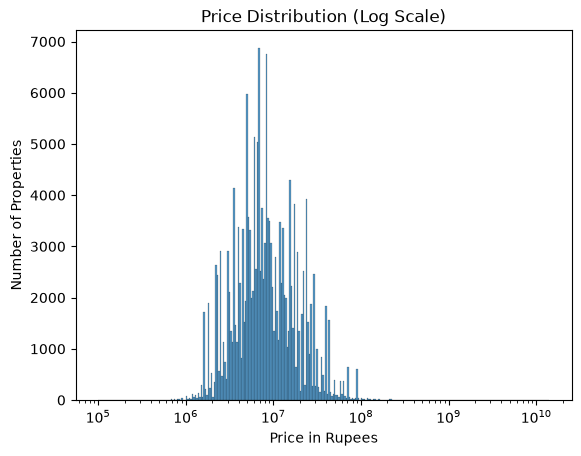

In [36]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(df["price_clean"], log_scale=True)
plt.title("Price Distribution (Log Scale)")
plt.xlabel("Price in Rupees")
plt.ylabel("Number of Properties")
plt.show()

In [37]:

#The price distribution is strongly right-skewed, with most properties concentrated in the lower to middle price range and a smaller number of properties having very high prices Using a logarithmic scale makes the distribution easier to visualize and highlights the presence of extreme high price values.

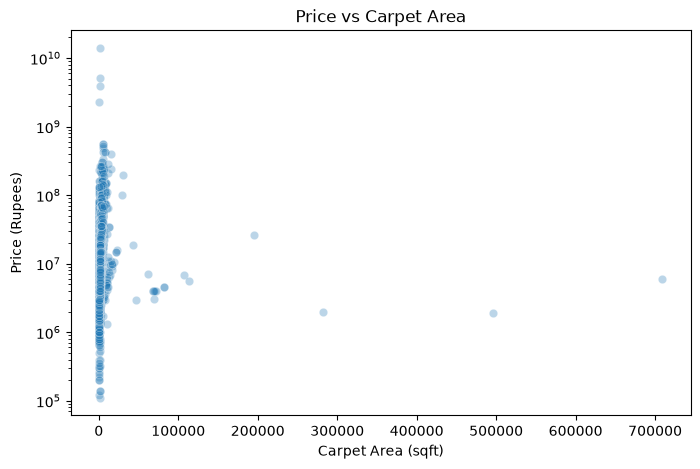

In [38]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="carpet_area_sqft",
    y="price_clean",
    alpha=0.3
)

plt.title("Price vs Carpet Area")
plt.xlabel("Carpet Area (sqft)")
plt.ylabel("Price (Rupees)")
plt.yscale("log")
plt.show()

In [39]:

#The scatter plot shows a generally positive relationship between carpet area and property price but the relationship is difficult to observe clearly because of extreme area and price values These outliers create a highly dispersed pattern and should be handled during the data cleaning stage.

In [40]:
df["price_per_sqft"] = df["price_clean"] / df["carpet_area_sqft"]

In [41]:
df["price_per_sqft"].describe()

count    1.015220e+05
mean     1.405568e+04
std      1.810217e+05
min      3.830877e+00
25%      5.444444e+03
50%      8.000000e+03
75%      1.311475e+04
max      4.000000e+07
Name: price_per_sqft, dtype: float64

In [42]:
lower = df["price_per_sqft"].quantile(0.01)
upper = df["price_per_sqft"].quantile(0.99)

print("1st percentile:", lower)
print("99th percentile:", upper)

1st percentile: 2705.8823529411766
99th percentile: 101503.75939849624


In [43]:
df = df[
    df["price_per_sqft"].isna() |
    df["price_per_sqft"].between(lower, upper)
].copy()

In [44]:
df.shape

(176293, 20)

In [45]:
missing = df.isnull().sum()
missing_percentage = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage
})

missing_table = missing_table.sort_values("Percentage", ascending=False)

missing_table

,Missing Values,Percentage
Society,102325,58.042577
super_area_sqft,100058,56.756649
Car_Parking_num,95260,54.035044
carpet_area_sqft,76325,43.294402
price_per_sqft,76325,43.294402
overlooking,75475,42.812250
facing,65415,37.105841
Ownership,61653,34.971893
Balcony_num,47113,26.724260
Price (in rupees),7833,4.443171


In [46]:
df["Bathroom_num"] = df["Bathroom_num"].fillna(0)
df["Balcony_num"] = df["Balcony_num"].fillna(0)
df["Car_Parking_num"] = df["Car_Parking_num"].fillna(0)

In [47]:
df[["Bathroom_num", "Balcony_num", "Car_Parking_num"]].isnull().sum()

Bathroom_num       0
Balcony_num        0
Car_Parking_num    0
dtype: int64

In [48]:
top_locations = df["location"].value_counts().head(50).index

df["location_grouped"] = df["location"].where(
    df["location"].isin(top_locations),
    "Other"
)

In [49]:
df["location_grouped"].nunique()

51

In [50]:
top_societies = df["Society"].value_counts().head(50).index

df["society_grouped"] = df["Society"].where(
    df["Society"].isin(top_societies),
    "Other"
)

In [51]:
df["society_grouped"].nunique()

51

In [52]:
df["facing"] = df["facing"].fillna(df["facing"].mode()[0])

In [53]:
df["facing"].isnull().sum()

np.int64(0)

In [54]:
df["overlooking"] = df["overlooking"].fillna(df["overlooking"].mode()[0])

In [55]:
df["overlooking"].isnull().sum()

np.int64(0)

In [56]:
df["Ownership"] = df["Ownership"].fillna(df["Ownership"].mode()[0])

In [57]:
df["Ownership"].isnull().sum()

np.int64(0)

In [58]:
df["Furnishing"] = df["Furnishing"].fillna(df["Furnishing"].mode()[0])

In [59]:
df["Furnishing"].isnull().sum()

np.int64(0)

In [60]:
df["Transaction"] = df["Transaction"].fillna(df["Transaction"].mode()[0])

In [61]:
df["Transaction"].isnull().sum()

np.int64(0)

In [62]:
df["floor_num"] = df["floor_num"].fillna(df["floor_num"].median())

In [63]:
df["floor_num"].isnull().sum()

np.int64(0)

In [64]:
missing = df.isnull().sum()
missing[missing > 0].sort_values(ascending=False)

Society              102325
super_area_sqft      100058
carpet_area_sqft      76325
price_per_sqft        76325
Price (in rupees)      7833
Description            2921
Status                  591
dtype: int64

In [65]:
df = df.drop(columns=[
    "Society",
    "Price (in rupees)",
    "Description",
    "Status",
    "price_per_sqft",
    "Index",
    "Title"
])

In [66]:
df.columns.tolist()

['location',
 'Transaction',
 'Furnishing',
 'facing',
 'overlooking',
 'Ownership',
 'price_clean',
 'carpet_area_sqft',
 'floor_num',
 'Bathroom_num',
 'Balcony_num',
 'Car_Parking_num',
 'super_area_sqft',
 'location_grouped',
 'society_grouped']

In [67]:
X = df.drop(columns=["price_clean"])
y = df["price_clean"]

In [68]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (176293, 14)
y shape: (176293,)


In [69]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [70]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (141034, 14)
X_test: (35259, 14)
y_train: (141034,)
y_test: (35259,)


In [128]:
numeric_features = [
    "carpet_area_sqft",
    "super_area_sqft",
    "floor_num",
    "Bathroom_num",
    "Balcony_num",
    "Car_Parking_num"
]

categorical_features = [
    "location_grouped",
    "society_grouped",
    "Furnishing",
    "Transaction",
    "Ownership",
    "facing",
    "overlooking"
]

In [129]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [115]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [116]:
from sklearn.preprocessing import OneHotEncoder

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [131]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [134]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['location','Transaction','Furnishing',...,'super_area_sqft', 'location_grouped','society_grouped']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [132]:
print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

Numeric features: ['carpet_area_sqft', 'super_area_sqft', 'floor_num', 'Bathroom_num', 'Balcony_num', 'Car_Parking_num']
Categorical features: ['location_grouped', 'society_grouped', 'Furnishing', 'Transaction', 'Ownership', 'facing', 'overlooking']


In [119]:
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [120]:
linear_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['location','Transaction','Furnishing',...,'super_area_sqft', 'location_grouped','society_grouped']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [135]:
y_pred_linear = linear_model.predict(X_test)

In [136]:
y_pred_linear[:10]

array([ 7598309.55465716, 39990453.15782747, 15432280.65651933,
        1992393.06848001, 14463448.13222539, 10966508.26576352,
       15432280.65651933, -3023675.28975173, -1691376.40167409,
       30265641.22648289])

In [123]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mean_squared_error(y_test, y_pred_linear))
r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression Results")
print("MAE:", mae_linear)
print("RMSE:", rmse_linear)
print("R²:", r2_linear)

Linear Regression Results
MAE: 3565227.390516873
RMSE: 8027989.055457619
R²: 0.6555871848768062


In [124]:
from sklearn.pipeline import Pipeline

In [125]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
numeric_features = ['num_col1', 'num_col2']
categorical_features = ['cat_col1', 'cat_col2']
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

In [126]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

In [127]:
print(X_train.columns.tolist())

['location', 'Transaction', 'Furnishing', 'facing', 'overlooking', 'Ownership', 'carpet_area_sqft', 'floor_num', 'Bathroom_num', 'Balcony_num', 'Car_Parking_num', 'super_area_sqft', 'location_grouped', 'society_grouped']


In [137]:
rf_model.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](14,)","['location','Transaction','Furnishing',...,'super_area_sqft', 'location_grouped','society_grouped']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,14
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed thr

In [140]:
print(y_train.name)
print(y_test.name)

price_clean
price_clean


In [138]:
y_pred_rf = rf_model.predict(X_test)

In [141]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1007478.3307124556
RMSE: 4984448.439571878
R²: 0.8672299939952651


In [143]:
import joblib

joblib.dump(rf_model, "house_price_model.pkl")

print("Model saved successfully!")

Model saved successfully!


In [144]:
import os

print(os.path.exists("house_price_model.pkl"))

True


In [87]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

print(results)

               Model           MAE          RMSE        R²
0  Linear Regression  3.565227e+06  8.027989e+06  0.655587
1      Random Forest  1.007478e+06  4.984448e+06  0.867230


In [91]:
import pandas as pd
import matplotlib.pyplot as plt

# Get the Random Forest model from the pipeline
rf = rf_model.named_steps["model"]

# Get feature importance
feature_importance = pd.Series(
    rf.feature_importances_
).sort_values(ascending=False)

print(feature_importance)

3      4.413704e-01
1      1.266216e-01
0      1.002034e-01
2      4.854905e-02
5      4.568978e-02
           ...     
63     5.899847e-08
130    2.941759e-08
113    2.758665e-08
104    9.168066e-09
144    1.390916e-09
Length: 145, dtype: float64


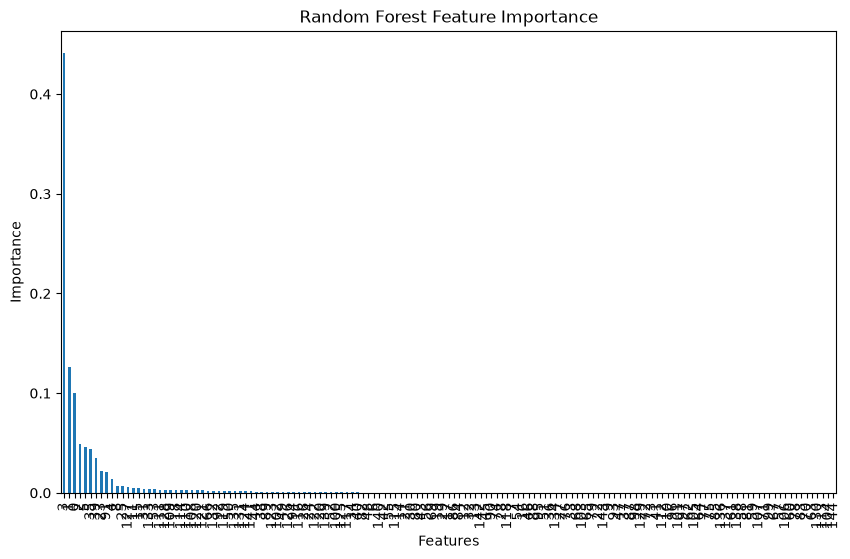

In [92]:
plt.figure(figsize=(10, 6))

feature_importance.plot(kind="bar")

plt.title("Random Forest Feature Importance")
plt.xlabel("Features")
plt.ylabel("Importance")

plt.show()

In [93]:
feature_names = preprocessor.get_feature_names_out()

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print(importance_df.head(10))

                            Feature  Importance
3                 num__Bathroom_num    0.441370
1              num__super_area_sqft    0.126622
0             num__carpet_area_sqft    0.100203
2                    num__floor_num    0.048549
5              num__Car_Parking_num    0.045690
35     cat__location_grouped_mumbai    0.043473
39  cat__location_grouped_new-delhi    0.035376
23    cat__location_grouped_gurgaon    0.021709
91       cat__society_grouped_Other    0.020807
4                  num__Balcony_num    0.013785


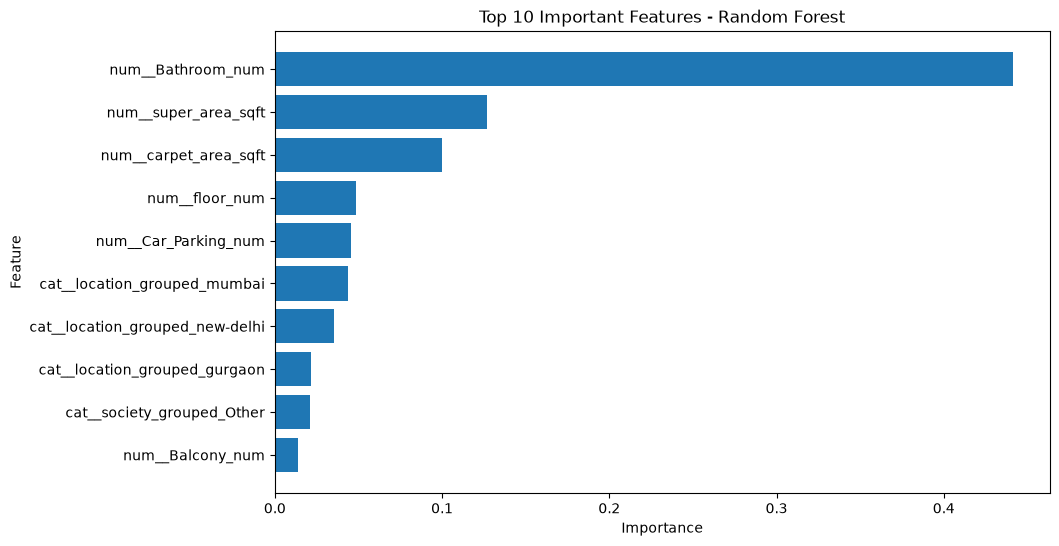

In [94]:
plt.figure(figsize=(10, 6))

top_features = importance_df.head(10)

plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 10 Important Features - Random Forest")
plt.gca().invert_yaxis()

plt.show()

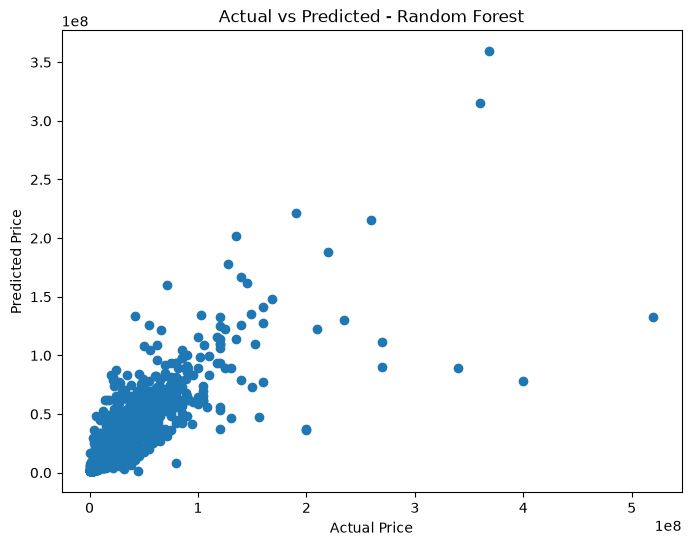

In [95]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

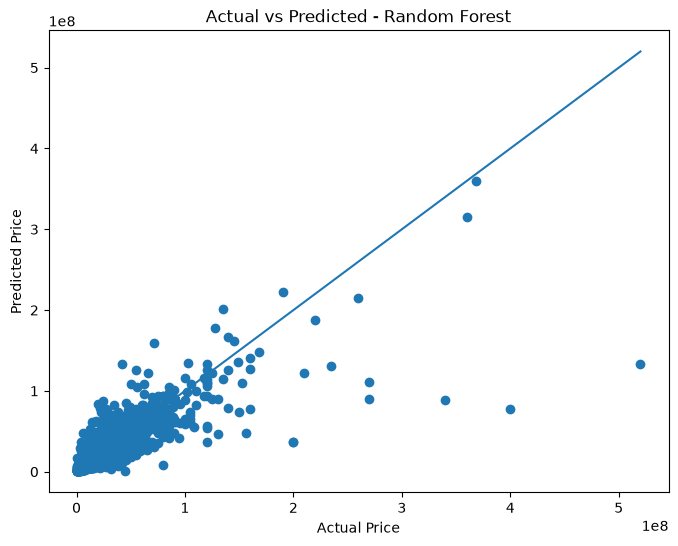

In [96]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_rf)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted - Random Forest")

plt.show()

In [97]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Results")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Results
MAE: 1007478.3307124556
RMSE: 4984448.439571878
R²: 0.8672299939952651


In [98]:
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "MAE": [mae_linear, mae_rf],
    "RMSE": [rmse_linear, rmse_rf],
    "R²": [r2_linear, r2_rf]
})

results

,Model,MAE,RMSE,R²
0,Linear Regression,3.565227e+06,8.027989e+06,0.655587
1,Random Forest,1.007478e+06,4.984448e+06,0.867230


In [99]:
import joblib
joblib.dump(rf_model, "house_price.pkl")

['house_price.pkl']

In [100]:
loaded_model = joblib.load("house_price.pkl")

sample = X_test.iloc[[0]]
sample_prediction = loaded_model.predict(sample)

print("Reloaded prediction:", sample_prediction[0])

Reloaded prediction: 8978433.333333332


In [101]:
import json

locations = sorted(df["location_grouped"].dropna().unique().tolist())

with open("locations.json", "w") as f:
    json.dump(locations, f)

print("Locations saved:", len(locations))

Locations saved: 51


In [102]:
print(locations[:10])

['Other', 'agra', 'ahmedabad', 'aurangabad', 'badlapur', 'bangalore', 'bhiwadi', 'bhubaneswar', 'chandigarh', 'chennai']
